# Volatilidad y Factores del Mercado

En este análisis me propongo analizar la volatilidad de las acciones de Apple e intentar comprender cuáles son los factores del mercado que generan dicha volatilidad.
El objetivo de este análisis es comprender los conceptos básicos del Análisis Financiero.


## Volatilidad

In [9]:
# imports necesarios

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
# Descargamos datos reales de Apple
# Usamos el método history para obtener precios recientes

appl = yf.Ticker("AAPL")
datos_reales = appl.history(period='3mo') # traemos los últimos 3 meses
datos_reales.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-03-13 00:00:00-04:00,255.244837,256.094046,249.290332,249.889771,36930000,0.0,0.0
2026-03-16 00:00:00-04:00,251.877942,253.656303,249.649999,252.587296,32074200,0.0,0.0
2026-03-17 00:00:00-04:00,252.727167,254.895168,251.947871,253.995987,32361600,0.0,0.0
2026-03-18 00:00:00-04:00,252.397472,254.705343,248.770808,249.709946,35757900,0.0,0.0
2026-03-19 00:00:00-04:00,249.170432,251.598204,247.072375,248.730850,34864100,0.0,0.0


In [3]:
# Calculamos la rentabilidad (retornos diarios)
# Utilizamos pct_change() de pandas obtener el cambio porcentual

retornos = datos_reales['Close'].pct_change().dropna() # utilizamos dropna() porque se genera un NaN con el primer día de nuestra serie histórica
print('Retornos (%): \n', (retornos.head() * 100).round(2))

Retornos (%): 
 Date
2026-03-16 00:00:00-04:00    1.08
2026-03-17 00:00:00-04:00    0.56
2026-03-18 00:00:00-04:00   -1.69
2026-03-19 00:00:00-04:00   -0.39
2026-03-20 00:00:00-04:00   -0.39
Name: Close, dtype: float64


### Estimación de localización (el centro)

In [4]:
# Calculamos la estimación de localización (la media y mediana)

media = retornos.mean()
mediana = retornos.median()

print('Media (%):\n', ((media * 100)).round(2))
print('Mediana (%): \n', ((mediana * 100)).round(2))

Media (%):
 0.25
Mediana (%): 
 0.31


### Estimación de la variabilidad o dispersión (el riesgo)

In [5]:
# Calculamos las desviaciones (errores o residuales)

desviaciones_media = retornos - media
desviaciones_mediana = retornos - mediana

print('residuales media (%): ', desviaciones_media.head()* 100)
print('residuales mediana (%): ', desviaciones_mediana.head() * 100)

residuales media (%):  Date
2026-03-16 00:00:00-04:00    0.826368
2026-03-17 00:00:00-04:00    0.304587
2026-03-18 00:00:00-04:00   -1.940562
2026-03-19 00:00:00-04:00   -0.645211
2026-03-20 00:00:00-04:00   -0.642742
Name: Close, dtype: float64
residuales mediana (%):  Date
2026-03-16 00:00:00-04:00    0.766845
2026-03-17 00:00:00-04:00    0.245063
2026-03-18 00:00:00-04:00   -2.000086
2026-03-19 00:00:00-04:00   -0.704734
2026-03-20 00:00:00-04:00   -0.702266
Name: Close, dtype: float64


In [6]:
# Aplicamos valor absoluto a las desviaciones de la mediana y extraemos la Desviacion Absoluta de la Mediana (MAD)

mad = desviaciones_mediana.abs().median()

print('MAD (%):', (mad * 100).round(2))

MAD (%): 0.84


In [7]:
# Calculamos la varianza

varianza = retornos.var()
print('varianza: ', varianza)

varianza:  0.00021097803479600265


In [8]:
# Calculamos la desviación estándar

desviacion_estandar = retornos.std()
print('desviación estándar:', desviacion_estandar * 100)

desviación estándar: 1.4525082953153923


#### Conclusión de Dispersión y Riesgo Individual (Volatilidad)
* **Riesgo "Típico" (MAD = 0.84%):** Es una estimación robusta de la variabilidad. Nos indica cuánto fluctúa la acción de Apple en un día de mercado normal, sin dejarse influenciar por días de pánico o euforia extrema.
* **Riesgo Total (Desviación Estándar = 1.45%):** Es la medida clásica de la volatilidad diaria. Al usar los residuales al cuadrado en su cálculo, captura y penaliza fuertemente los movimientos extremos del mercado.
* **Diagnóstico Financiero:** La desviación estándar es casi dos veces mayor que la MAD.
 Este hecho no es sorprendente, ya que la desviación estándar es sensible a valores atípicos. Esta gran diferencia nos confirma empíricamente que la acción de Apple sufre días de fluctuaciones extremas que elevan sustancialmente su perfil de riesgo general.

### Exploración de la distribución de datos

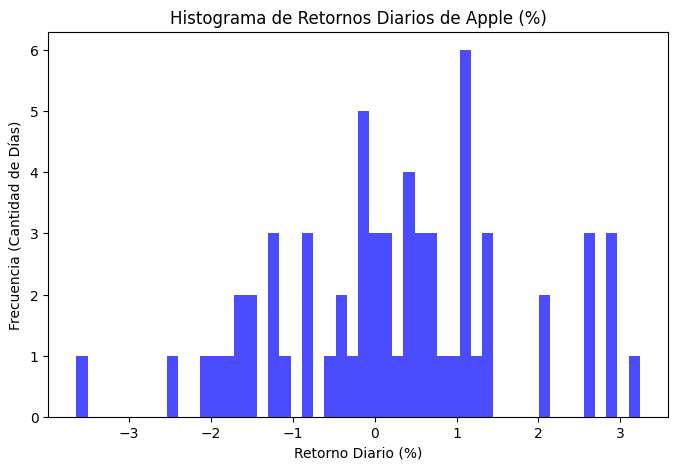

In [10]:
# Visualización de la distribución de los retornos

# A. Histograma (para ver la concentración de los datos)
ax_hist = (retornos * 100).plot.hist(bins=50, figsize=(8, 5), color='blue', alpha=0.7)
ax_hist.set_title('Histograma de Retornos Diarios de Apple (%)')
ax_hist.set_xlabel('Retorno Diario (%)')
ax_hist.set_ylabel('Frecuencia (Cantidad de Días)')
plt.show()

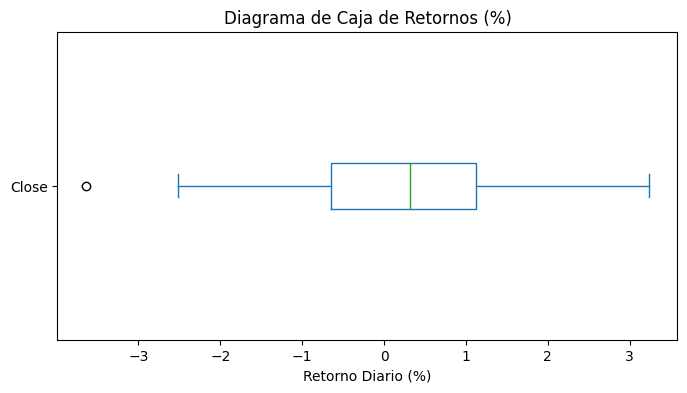

In [15]:
# Diagrama de Caja / Boxplot 
ax_box = (retornos * 100).plot.box(figsize=(8, 4), vert=False)
ax_box.set_title('Diagrama de Caja de Retornos (%)')
ax_box.set_xlabel('Retorno Diario (%)') # Ahora el porcentaje se lee en el eje X
plt.show()

## Factores de Mercado

### Correlación